In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [2]:
# Choose the used-cars CSV file from your computer
from google.colab import files
uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()

Saving Medicaldataset (1).csv to Medicaldataset (1).csv
Shape: (1319, 9)


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [4]:
df.isnull().sum()

,0
Age,0
Gender,0
Heart rate,0
Systolic blood pressure,0
Diastolic blood pressure,0
Blood sugar,0
CK-MB,0
Troponin,0
Result,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [7]:

# univariate

print(df["Result"].value_counts(normalize=True) * 100)

Result
positive    61.410159
negative    38.589841
Name: proportion, dtype: float64


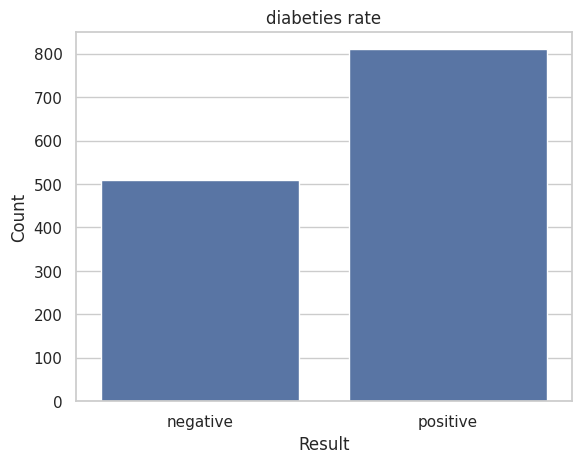

In [8]:
sns.countplot(data=df, x="Result")
plt.title("diabeties rate")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

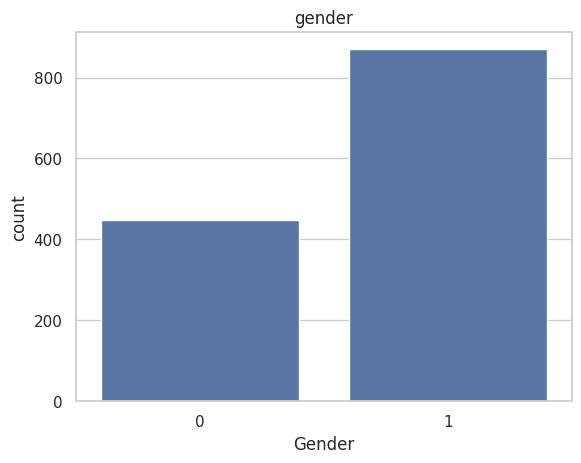

In [9]:
sns.countplot(data=df, x="Gender")
plt.title("gender")
plt.show()

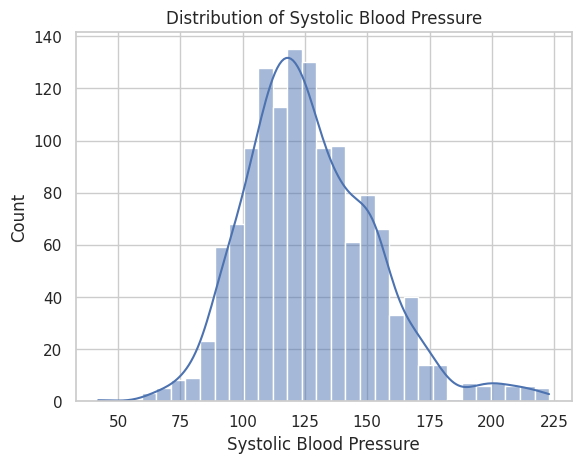

In [20]:
sns.histplot(data=df, x="Systolic blood pressure", kde=True)

plt.title("Distribution of Systolic Blood Pressure")
plt.xlabel("Systolic Blood Pressure")
plt.ylabel("Count")

plt.show()

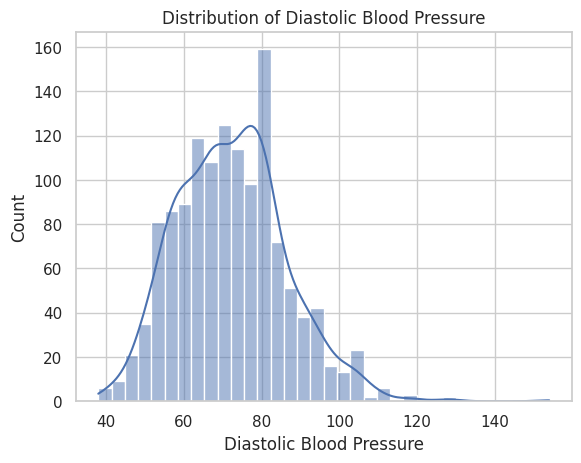

In [21]:
sns.histplot(data=df, x="Diastolic blood pressure", kde=True)

plt.title("Distribution of Diastolic Blood Pressure")
plt.xlabel("Diastolic Blood Pressure")
plt.ylabel("Count")

plt.show()

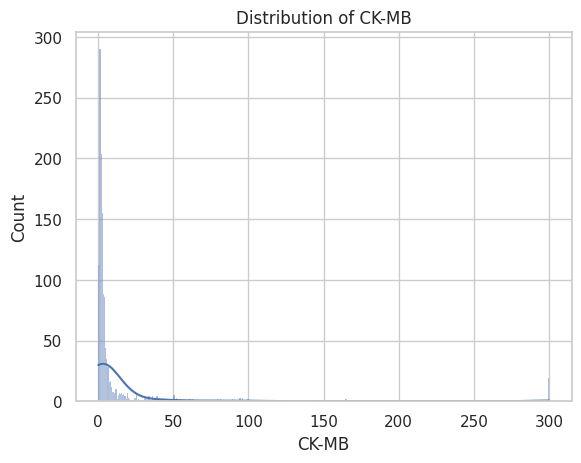

In [22]:
sns.histplot(data=df, x="CK-MB", kde=True)

plt.title("Distribution of CK-MB")
plt.xlabel("CK-MB")
plt.ylabel("Count")

plt.show()

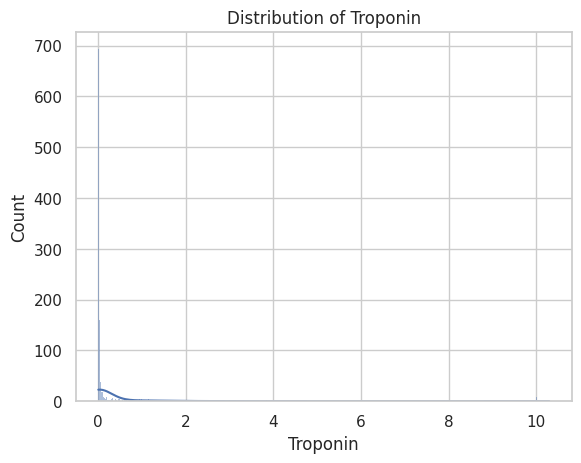

In [23]:
sns.histplot(data=df, x="Troponin", kde=True)

plt.title("Distribution of Troponin")
plt.xlabel("Troponin")
plt.ylabel("Count")

plt.show()

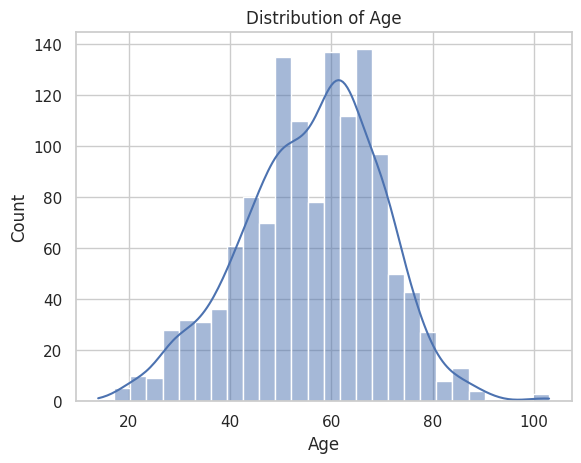

In [24]:
sns.histplot(data=df, x="Age", kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [25]:
print(df["Result"].unique())

['negative' 'positive']


In [26]:
print(df["Result"].value_counts())

Result
positive    810
negative    509
Name: count, dtype: int64


In [27]:
X = df.drop("Result", axis=1)

print(X.head())

   Age  Gender  Heart rate  Systolic blood pressure  Diastolic blood pressure  \
0   64       1          66                      160                        83   
1   21       1          94                       98                        46   
2   55       1          64                      160                        77   
3   64       1          70                      120                        55   
4   55       1          64                      112                        65   

   Blood sugar  CK-MB  Troponin  
0        160.0   1.80     0.012  
1        296.0   6.75     1.060  
2        270.0   1.99     0.003  
3        270.0  13.87     0.122  
4        300.0   1.08     0.003  


In [28]:
y = df["Result"]

print(y.head())

0    negative
1    positive
2    negative
3    positive
4    negative
Name: Result, dtype: object


In [29]:
X = pd.get_dummies(X, columns=["Gender"], drop_first=True)

print(X.head())

   Age  Heart rate  Systolic blood pressure  Diastolic blood pressure  \
0   64          66                      160                        83   
1   21          94                       98                        46   
2   55          64                      160                        77   
3   64          70                      120                        55   
4   55          64                      112                        65   

   Blood sugar  CK-MB  Troponin  Gender_1  
0        160.0   1.80     0.012      True  
1        296.0   6.75     1.060      True  
2        270.0   1.99     0.003      True  
3        270.0  13.87     0.122      True  
4        300.0   1.08     0.003      True  


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1055, 8)
X_test: (264, 8)
y_train: (1055,)
y_test: (264,)


In [31]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

Missing values in X_train:
Age                         0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Gender_1                    0
dtype: int64


In [33]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print("Imputation completed.")

Imputation completed.


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", random_state=42)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [36]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['positive' 'negative' 'positive' 'negative' 'negative' 'positive'
 'positive' 'positive' 'positive' 'positive' 'negative' 'negative'
 'negative' 'positive' 'negative' 'negative' 'negative' 'negative'
 'negative' 'negative' 'positive' 'positive' 'positive' 'negative'
 'negative' 'negative' 'positive' 'negative' 'negative' 'positive'
 'negative' 'negative' 'negative' 'positive' 'positive' 'positive'
 'negative' 'positive' 'negative' 'positive' 'negative' 'negative'
 'negative' 'positive' 'positive' 'negative' 'positive' 'positive'
 'negative' 'positive' 'negative' 'positive' 'negative' 'positive'
 'negative' 'negative' 'negative' 'positive' 'positive' 'negative'
 'negative' 'positive' 'positive' 'positive' 'negative' 'negative'
 'negative' 'positive' 'negative' 'negative' 'positive' 'negative'
 'positive' 'positive' 'negative' 'negative' 'negative' 'positive'
 'positive' 'negative' 'negative' 'negative' 'negative' 'positive'
 'negative' 'positive' 'positive' 'negative' 'neg

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="positive")
recall = recall_score(y_test, y_pred, pos_label="positive")
f1 = f1_score(y_test, y_pred, pos_label="positive")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7878787878787878
Precision: 0.9206349206349206
Recall   : 0.7160493827160493
F1-score : 0.8055555555555556


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=["negative", "positive"])

print(cm)

[[ 92  10]
 [ 46 116]]


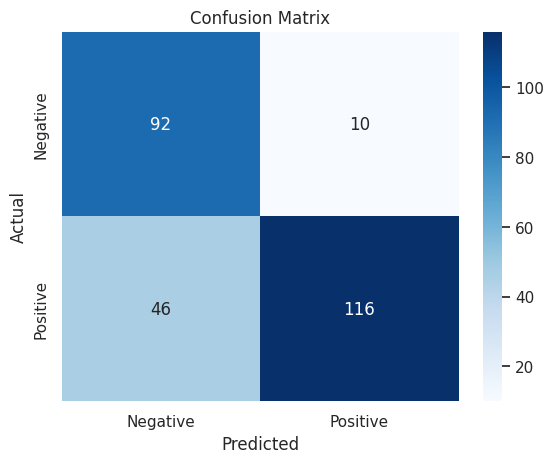

In [40]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
from sklearn.metrics import roc_auc_score

y_test_binary = (y_test == "positive").astype(int)
y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test_binary, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8877390462357783


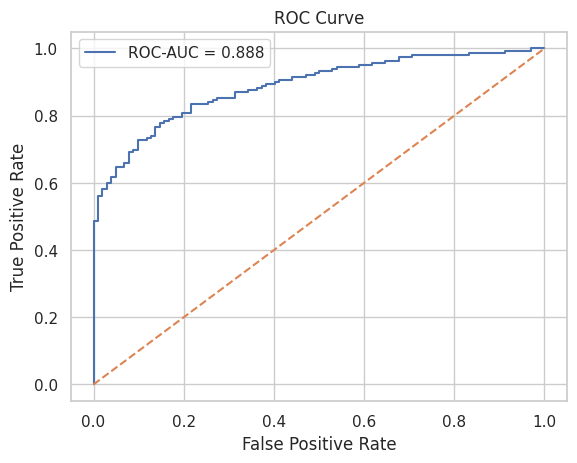

In [42]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

In [43]:
feature_names = X.columns

coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

print(coef_df)

                    Feature  Coefficient
0                       Age     0.583274
1                Heart rate     0.028785
2   Systolic blood pressure    -0.114894
3  Diastolic blood pressure     0.068574
4               Blood sugar    -0.091924
5                     CK-MB     5.898225
6                  Troponin     3.245032
7                  Gender_1     0.214855


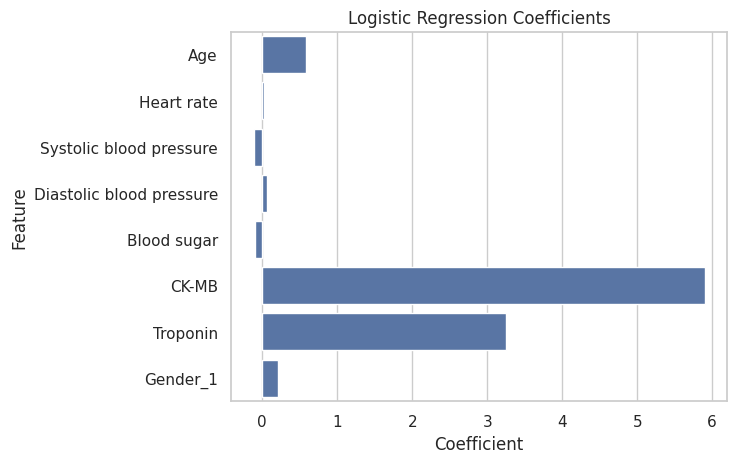

In [44]:
sns.barplot(data=coef_df, x="Coefficient", y="Feature")

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [45]:
coef_df = coef_df.sort_values("Coefficient", ascending=False)

print(coef_df)

                    Feature  Coefficient
5                     CK-MB     5.898225
6                  Troponin     3.245032
0                       Age     0.583274
7                  Gender_1     0.214855
3  Diastolic blood pressure     0.068574
1                Heart rate     0.028785
4               Blood sugar    -0.091924
2   Systolic blood pressure    -0.114894


In [46]:
print("===== LOGISTIC REGRESSION MODEL RESULTS =====")

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1-score :", round(f1, 3))
print("ROC-AUC  :", round(roc_auc, 3))

===== LOGISTIC REGRESSION MODEL RESULTS =====
Accuracy : 0.788
Precision: 0.921
Recall   : 0.716
F1-score : 0.806
ROC-AUC  : 0.888


In [47]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

results

,Metric,Score
0,Accuracy,0.787879
1,Precision,0.920635
2,Recall,0.716049
3,F1-score,0.805556
4,ROC-AUC,0.887739
